In [1]:
from pathlib import Path
import xarray as xr
import pandas as pd
import numpy as np

data_dir = Path(r"D:\INCOIS\Data_Float_Fixed")
phyto_list = []

In [4]:
files = sorted(data_dir.glob("*.nc"))

for i, file in enumerate(files):

    ds = xr.open_dataset(file)

    bob = ds.sel(
        lat=slice(20, 17),
        lon=slice(84, 87)
    )

    # Mask where either input is NaN
    nan_mask = bob["CHLOR_A"].isnull() | bob["PhytoID"].isnull()

    phytobloom = xr.where(
        nan_mask,
        np.nan,
        xr.where(
            (bob["PhytoID"] == 1) &
            (bob["CHLOR_A"] > 1),

            1,

            xr.where(
                (bob["PhytoID"] == 2) &
                (bob["CHLOR_A"] > 1),

                2,

                0
            )
        )
    )

    date = pd.to_datetime(
        file.name[1:9],
        format="%Y%m%d"
    )

    phytobloom = phytobloom.expand_dims(
        time=[date]
    )

    phyto_list.append(phytobloom)

    ds.close()

    if (i + 1) % 100 == 0:
        print(f"{i+1}/{len(files)}")

100/8344
200/8344
300/8344
400/8344
500/8344
600/8344
700/8344
800/8344
900/8344
1000/8344
1100/8344
1200/8344
1300/8344
1400/8344
1500/8344
1600/8344
1700/8344
1800/8344
1900/8344
2000/8344
2100/8344
2200/8344
2300/8344
2400/8344
2500/8344
2600/8344
2700/8344
2800/8344
2900/8344
3000/8344
3100/8344
3200/8344
3300/8344
3400/8344
3500/8344
3600/8344
3700/8344
3800/8344
3900/8344
4000/8344
4100/8344
4200/8344
4300/8344
4400/8344
4500/8344
4600/8344
4700/8344
4800/8344
4900/8344
5000/8344
5100/8344
5200/8344
5300/8344
5400/8344
5500/8344
5600/8344
5700/8344
5800/8344
5900/8344
6000/8344
6100/8344
6200/8344
6300/8344
6400/8344
6500/8344
6600/8344
6700/8344
6800/8344
6900/8344
7000/8344
7100/8344
7200/8344
7300/8344
7400/8344
7500/8344
7600/8344
7700/8344
7800/8344
7900/8344
8000/8344
8100/8344
8200/8344
8300/8344


In [5]:
phyto = xr.concat(
    phyto_list,
    dim="time"
)

phyto_ds = phyto.to_dataset(
    name="PHYTOBLOOM"
)

print(phyto_ds)

<xarray.Dataset> Size: 349MB
Dimensions:     (time: 8425, lon: 72, lat: 72)
Coordinates:
  * time        (time) datetime64[us] 67kB 2003-01-01 2003-01-02 ... 2025-11-30
  * lon         (lon) float32 288B 84.02 84.06 84.1 84.15 ... 86.9 86.94 86.98
  * lat         (lat) float32 288B 19.98 19.94 19.9 19.85 ... 17.1 17.06 17.02
Data variables:
    PHYTOBLOOM  (time, lat, lon) float64 349MB nan nan nan nan ... nan nan nan


In [6]:
phyto_ds.to_netcdf(
    r"D:\INCOIS\PHYTOBLOOM_BOB.nc"
)

In [4]:
import xarray as xr, numpy as np

phyto_ds = xr.open_dataset(
    r"D:\INCOIS\PHYTOBLOOM_BOB.nc"
)

In [5]:
phyto_ds

<xarray.Dataset> Size: 349MB
Dimensions:     (time: 8425, lat: 72, lon: 72)
Coordinates:
  * time        (time) datetime64[ns] 67kB 2003-01-01 2003-01-02 ... 2025-11-30
  * lat         (lat) float32 288B 19.98 19.94 19.9 19.85 ... 17.1 17.06 17.02
  * lon         (lon) float32 288B 84.02 84.06 84.1 84.15 ... 86.9 86.94 86.98
Data variables:
    PHYTOBLOOM  (time, lat, lon) float64 349MB ...

In [8]:
import xarray as xr, numpy as np

test = xr.open_dataset(
    r"D:\INCOIS\PHYTOBLOOM_BOB_C.nc"
)

# print(
#     np.unique(
#         test["PHYTOBLOOM"]
#         .isel(time=0)
#         .values
#     )
# )
print(
    np.unique(
        test["PHYTOBLOOM"].values
    )
)

[ 0.  1.  2. nan]


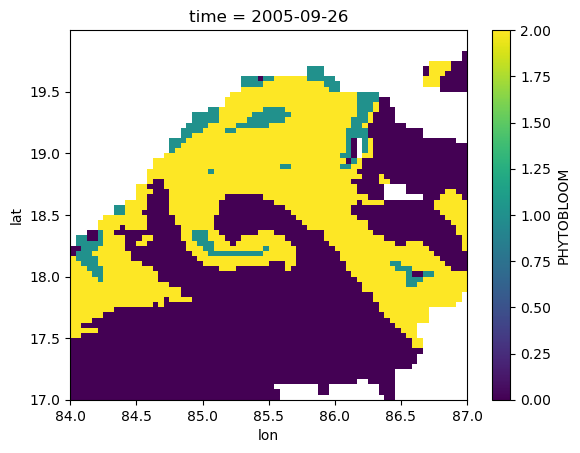

In [9]:
test["PHYTOBLOOM"].sel(time="2005-09-26").plot()

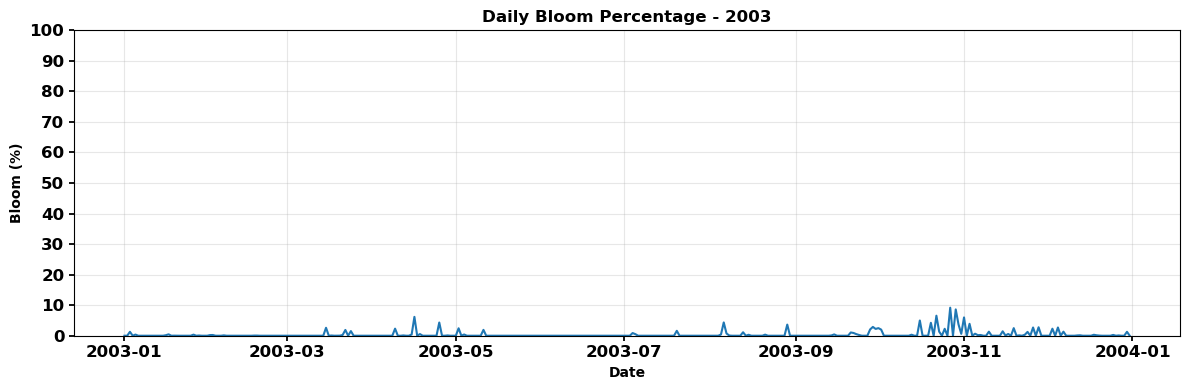

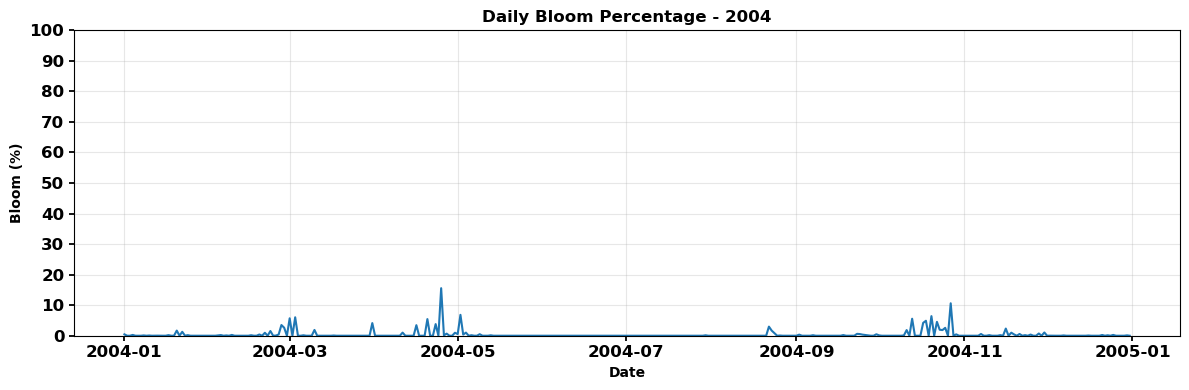

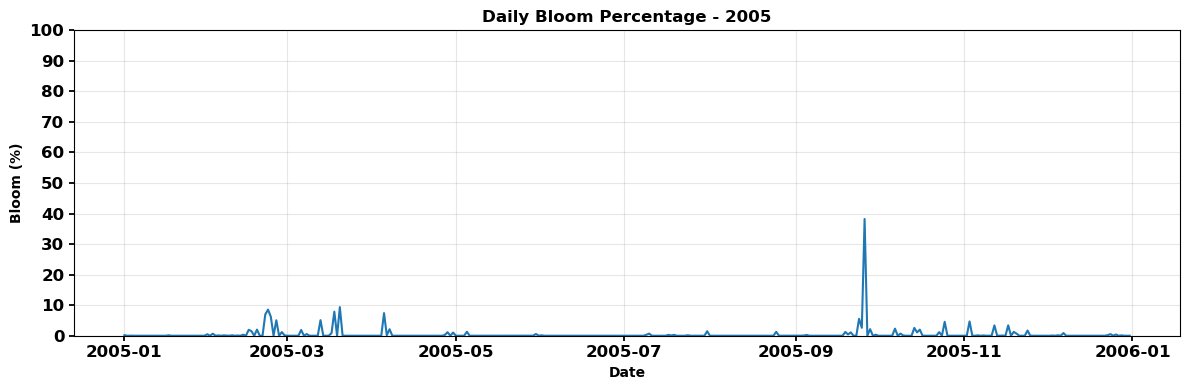

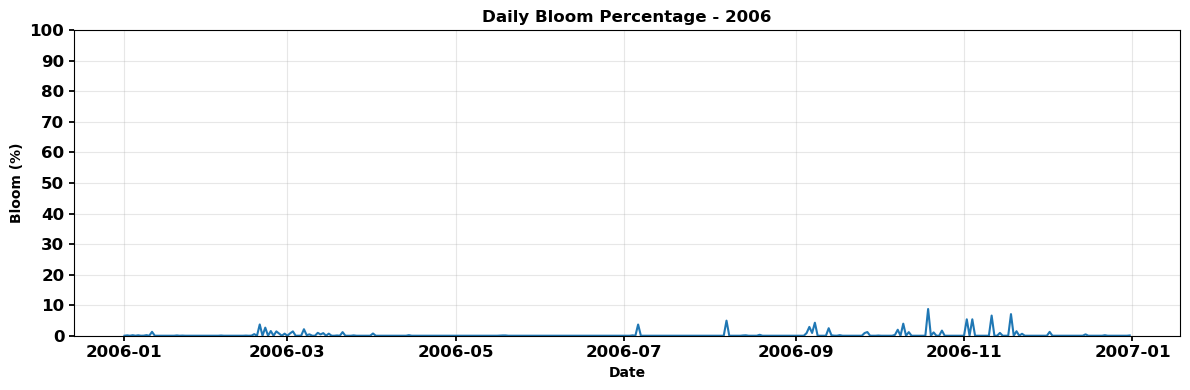

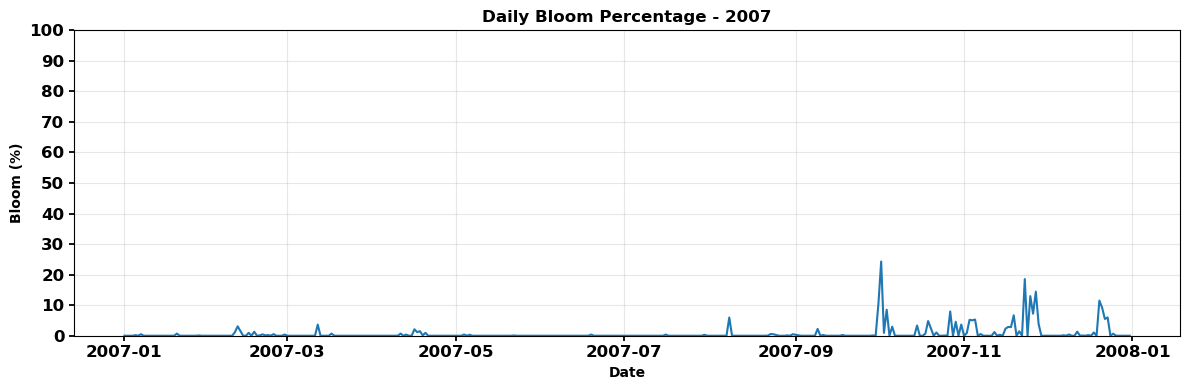

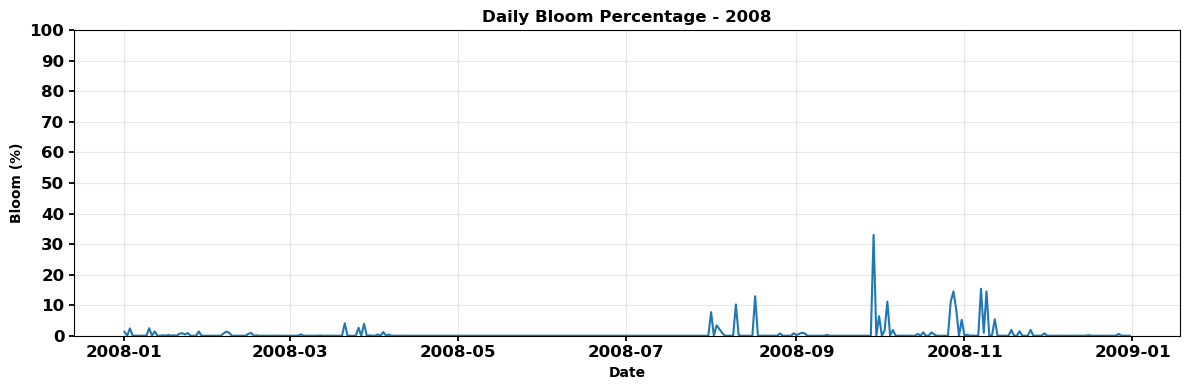

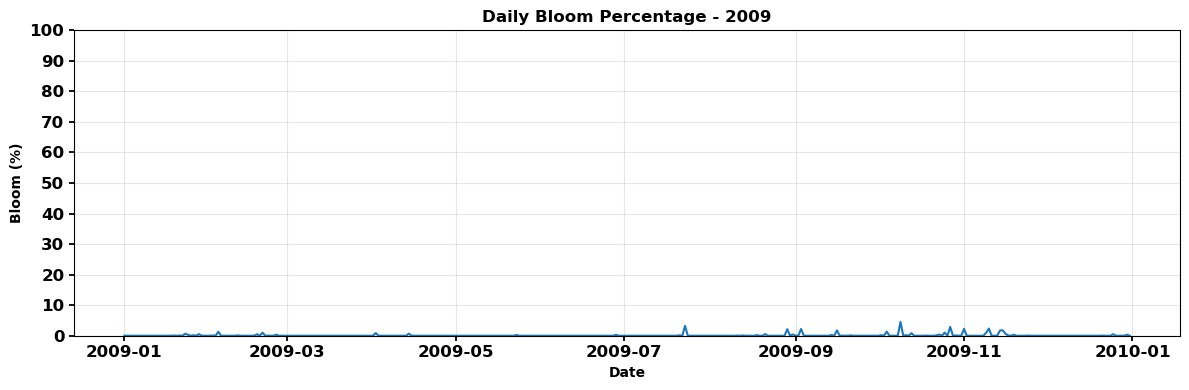

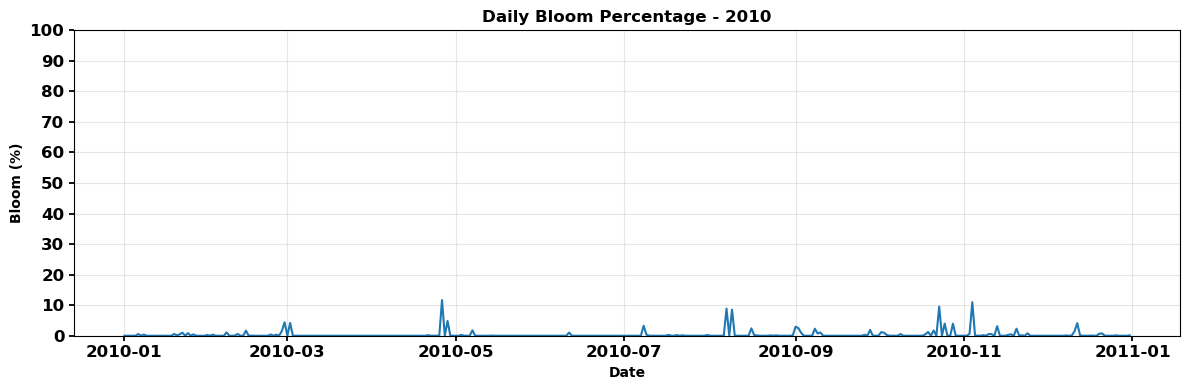

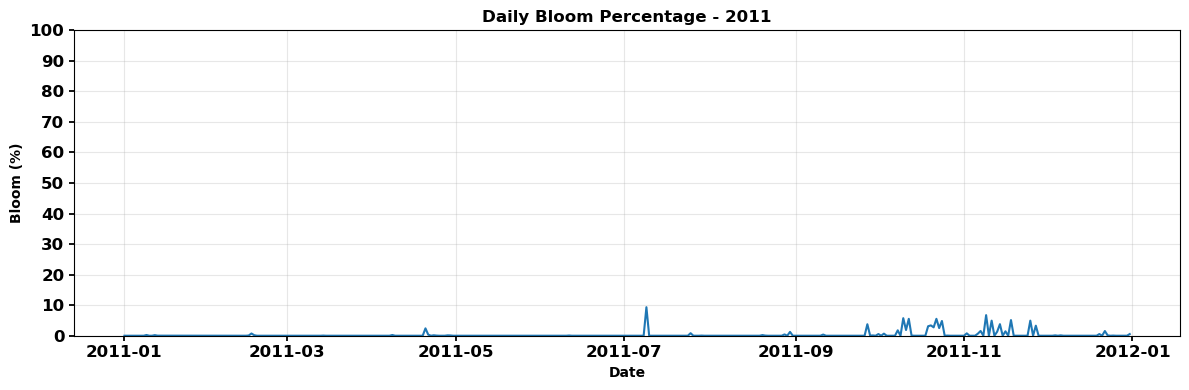

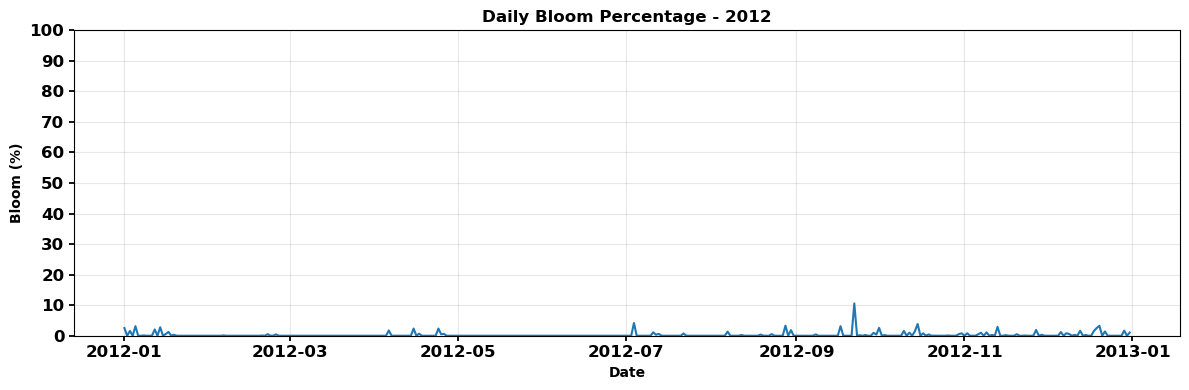

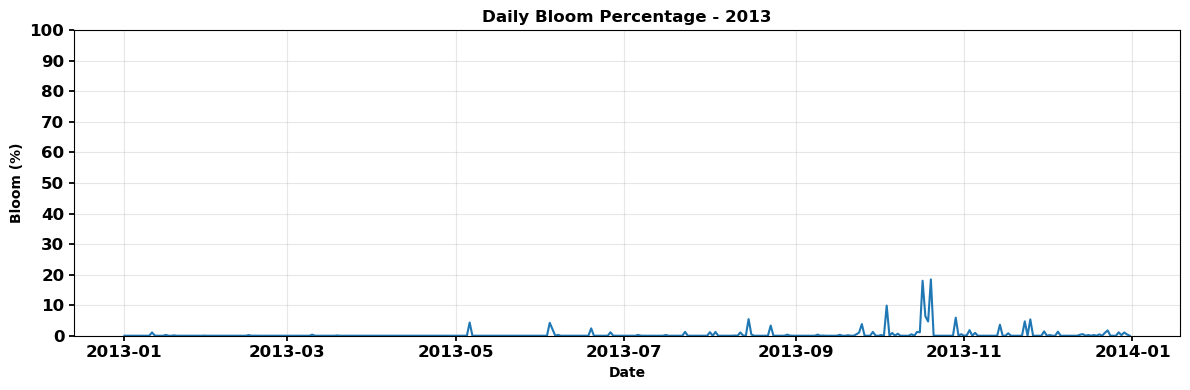

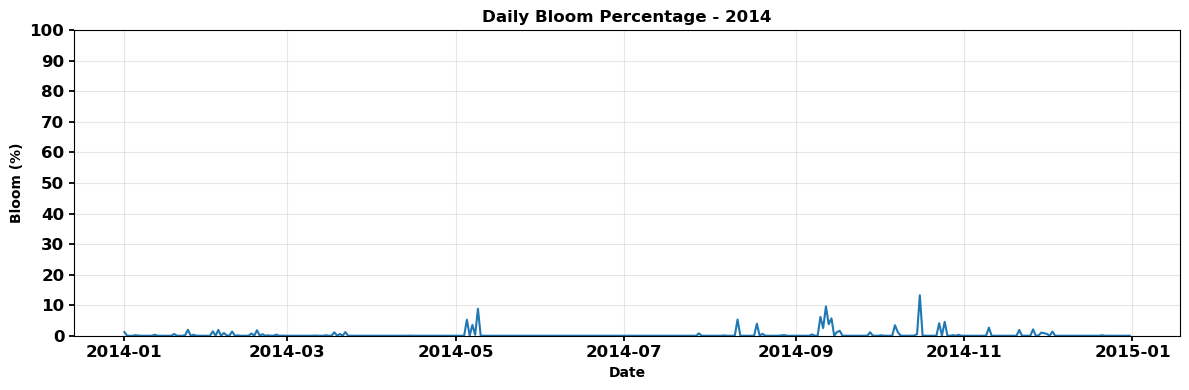

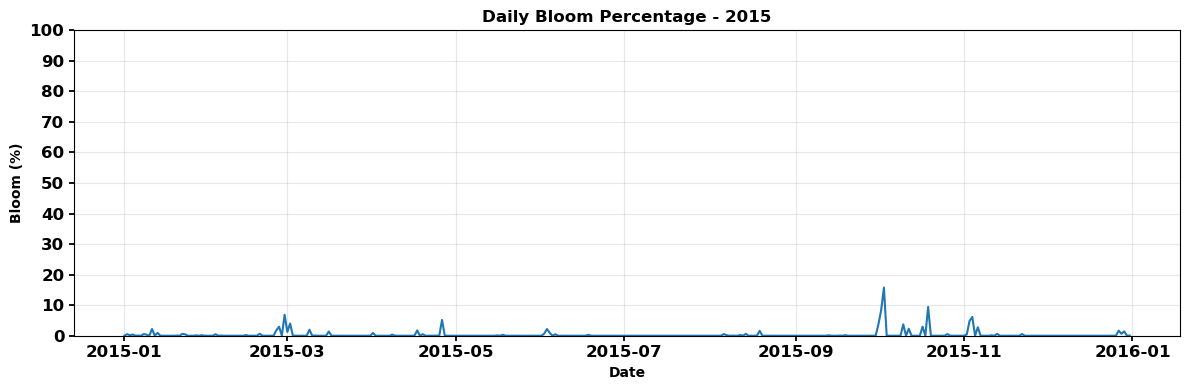

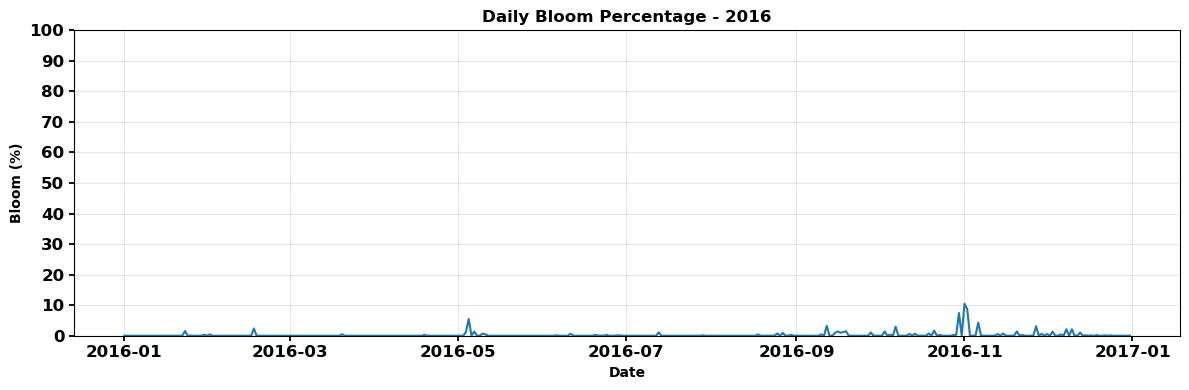

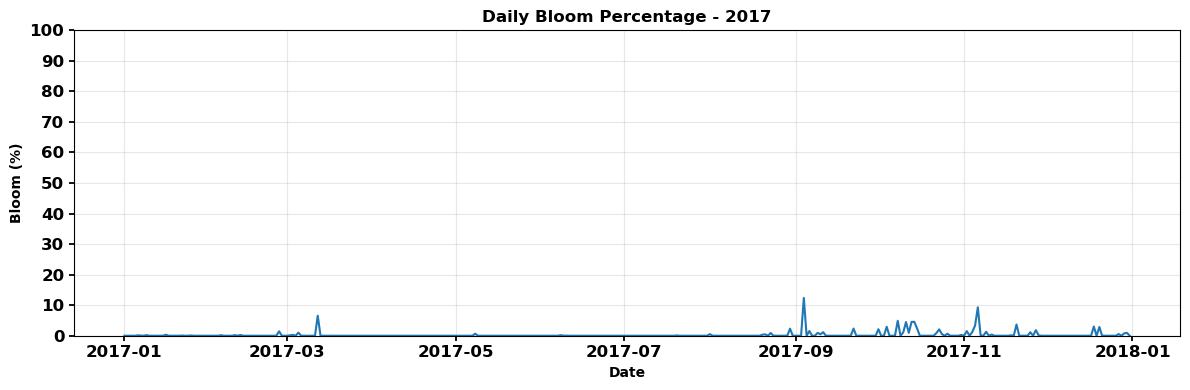

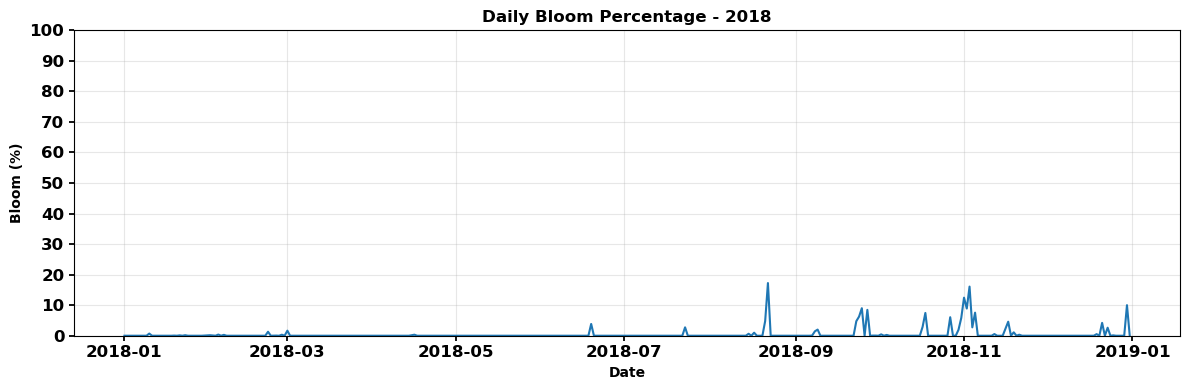

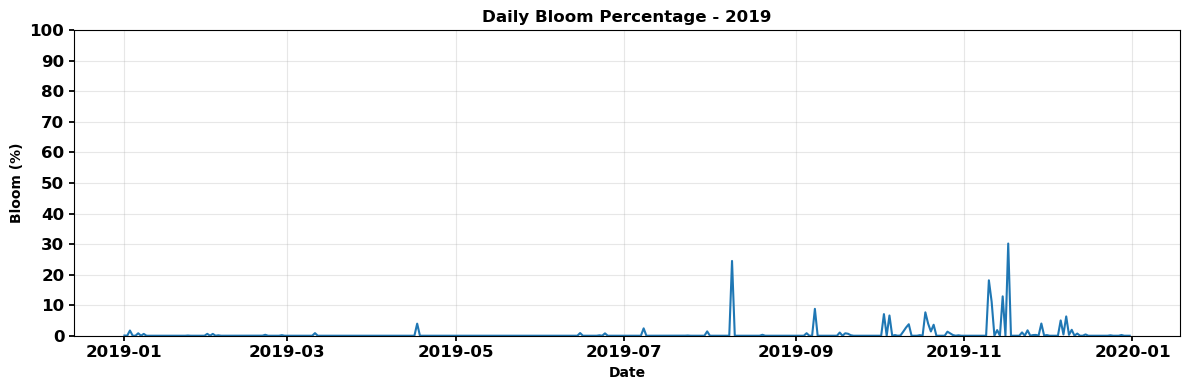

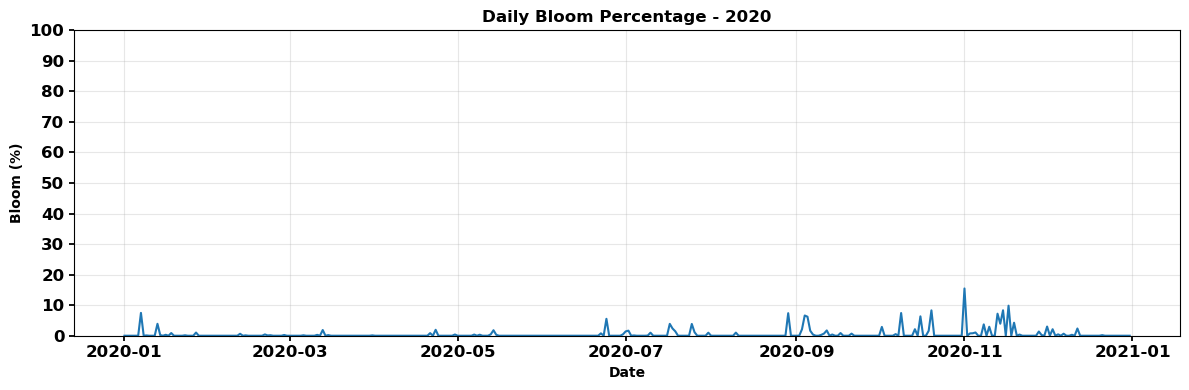

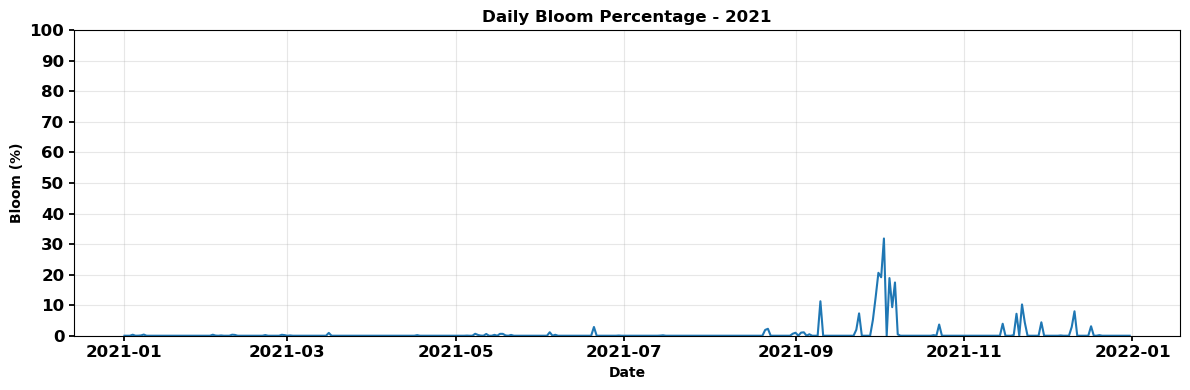

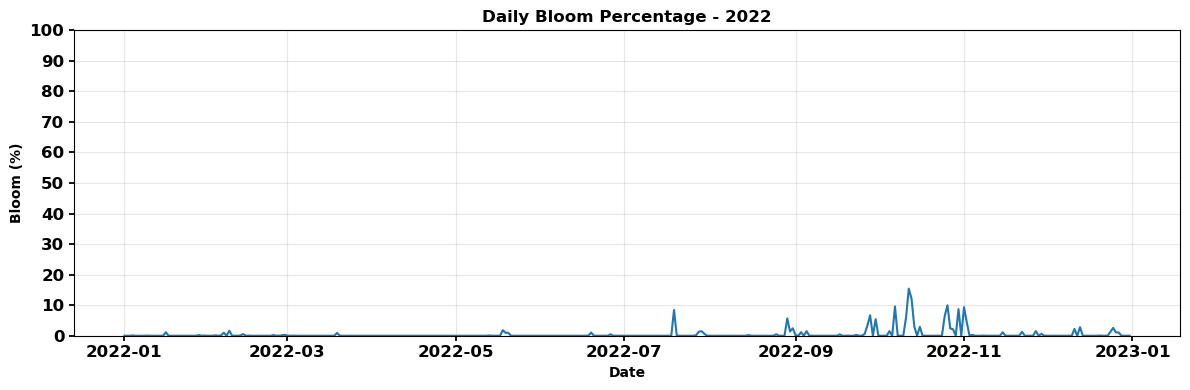

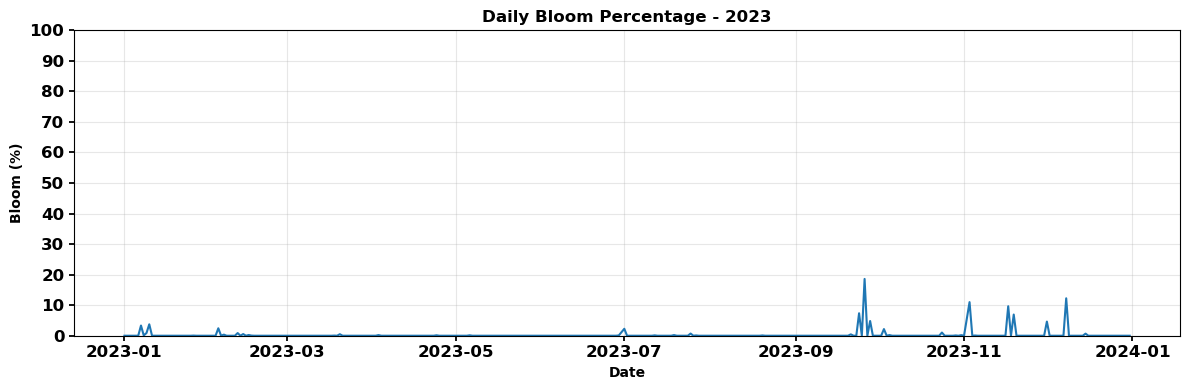

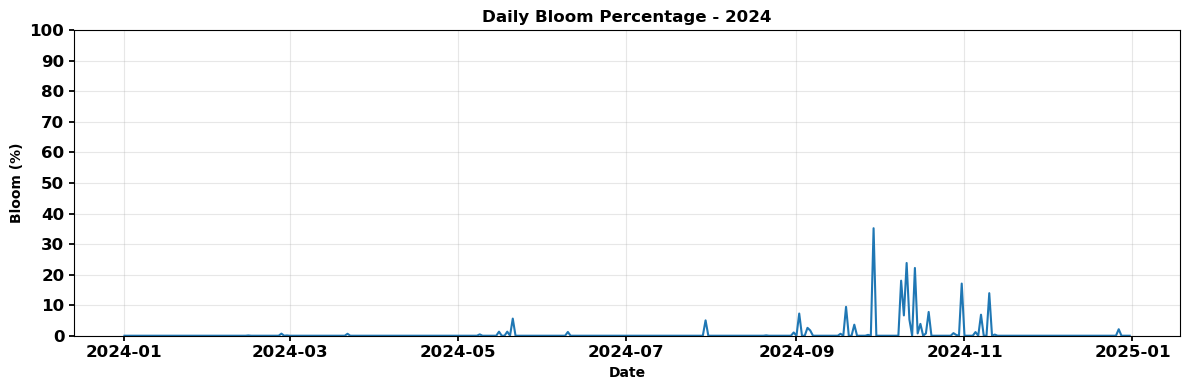

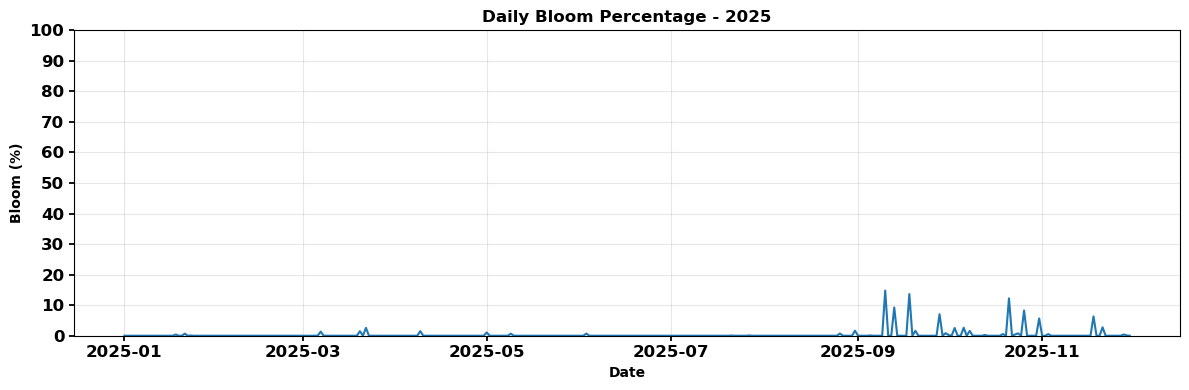

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from global_land_mask import globe  # pip install global-land-mask

ds = xr.open_dataset(r"D:\INCOIS\PHYTOBLOOM_BOB_C.nc")

# ── Build a land mask on this dataset's own lat/lon grid ─────────────────────
lat_vals = ds["lat"].values
lon_vals = ds["lon"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
land_mask = globe.is_land(lat_grid, lon_grid)          # True over land
ocean_mask = ~land_mask                                  # True over ocean/water

# Number of ocean (non-land) pixels — this is the correct denominator
total_pixels = ocean_mask.sum()

# Wrap ocean_mask as an xarray DataArray so it broadcasts correctly against
# PHYTOBLOOM's (time, lat, lon) dims
ocean_mask_da = xr.DataArray(
    ocean_mask,
    dims=("lat", "lon"),
    coords={"lat": ds["lat"], "lon": ds["lon"]}
)

# Only count bloom pixels that are actually over ocean
phyto_ocean = ds["PHYTOBLOOM"].where(ocean_mask_da)

bloom_percent = (
    (phyto_ocean > 0).sum(dim=("lat", "lon")) / total_pixels
) * 100

years = np.unique(bloom_percent.time.dt.year)

for year in years:

    yearly = bloom_percent.sel(time=str(year))

    plt.figure(figsize=(12, 4))
    plt.plot(yearly.time.values, yearly.values, lw=1.5)

    plt.title(f"Daily Bloom Percentage - {year}", fontweight='bold')
    plt.xlabel("Date", fontweight='bold')
    plt.ylabel("Bloom (%)", fontweight='bold')

    plt.ylim(0, 100)
    plt.yticks(np.arange(0, 101, 10))
    plt.tick_params(axis="both", labelsize=12, width=1.3)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontweight("bold")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()